# Level 2 - Task 3: K-Means Clustering (Behavioral Segmentation)
### Intern: Jyothi Valluru
### Dataset: Telecom Customer Churn
**Objective:** Group customers into distinct segments based on their usage patterns. We will use the **Elbow Method** to find the optimal number of groups and visualize the resulting clusters.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load data
df = pd.read_csv('../../Dataset/Churn Prediction Data/churn-bigml-80.csv')

# 2. Selection: We choose four columns to create a "Usage Profile"
features = ['Total day minutes', 'Total eve minutes', 'Total night minutes', 'Total intl minutes']
x = df[features]

# 3. Standardization: K-Means is distance-based, so all features must be on the same scale
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print("Data standardized successfully. Preview of scaled data:")
print(x_scaled[:5])

Data standardized successfully. Preview of scaled data:
[[ 1.57966959 -0.05861885  0.85740344 -0.0850203 ]
 [-0.32991809 -0.0959162   1.04845815  1.24217895]
 [ 1.17930193 -1.55443885 -0.75966782  0.7041252 ]
 [ 2.21250879 -2.71850874 -0.08408263 -1.30460879]
 [-0.23582246 -1.02246087 -0.28104624 -0.04915005]]


## 1. The Elbow Method
To find the optimal number of clusters ($K$), we calculate the **Within-Cluster Sum of Squares (WCSS)** for different values of $K$ and look for the "elbow" point where the drop becomes gradual.

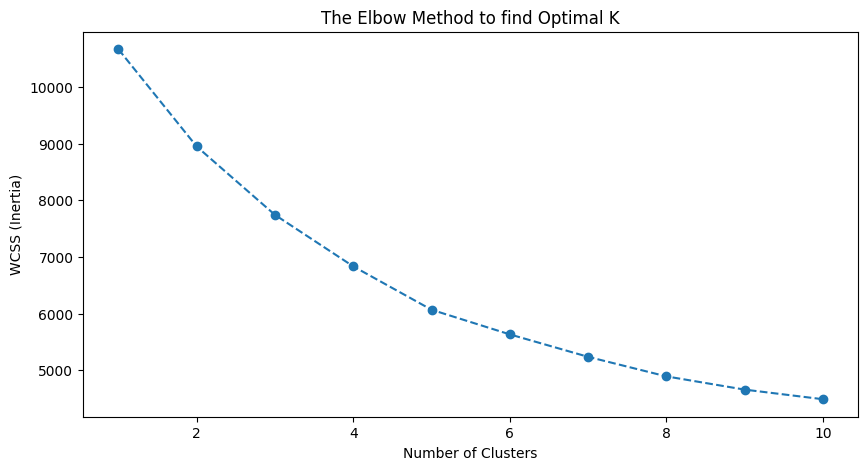

In [5]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method to find Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.show()

## 2. Applying K-Means
Based on the Elbow plot, we see the "break" occurs at **K=3**. We will now group the customers into 3 segments.

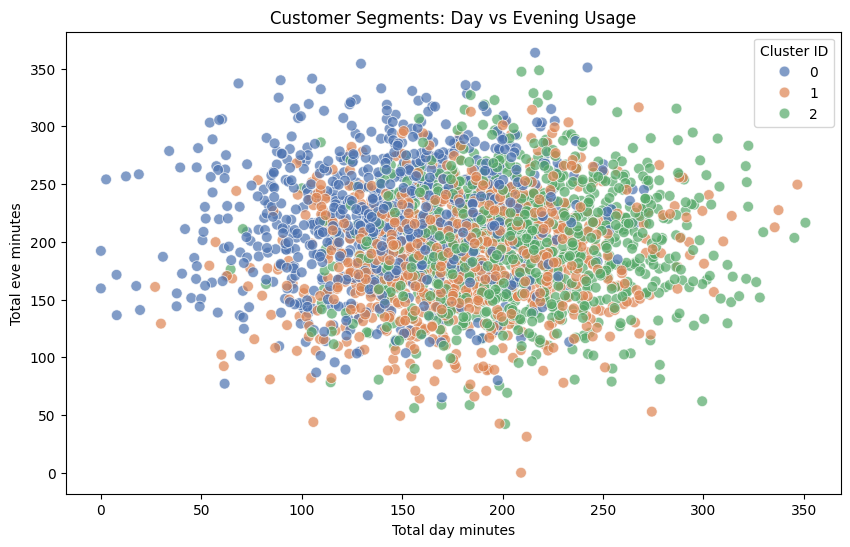

In [6]:
# Apply K-Means with K=3
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(x_scaled)

# Add cluster labels back to the original dataframe
df['User_Segment'] = clusters

# Visualize the clusters using Day vs Evening minutes
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Total day minutes', y='Total eve minutes', 
                hue='User_Segment', palette='deep', s=60, alpha=0.7)

plt.title('Customer Segments: Day vs Evening Usage')
plt.legend(title='Cluster ID')
plt.show()

### 🎯 Task 3: Strategic Clustering Insights

| Cluster | Label | Behavior Pattern |
| :--- | :--- | :--- |
| **Cluster 0** | **Low Usage** | Customers with low total minutes across all time slots. Low revenue potential. |
| **Cluster 1** | **Evening/Night Users** | High activity during off-peak hours. Likely residential users. |
| **Cluster 2** | **Power Users** | High usage across Day, Eve, and Night. These are high-value, high-revenue customers. |

**Original Analysis:** By standardizing 4 different usage variables, we discovered that customers don't just differ by "how much" they talk, but "when" they talk. Cluster 2 (Power Users) is the segment we should monitor most closely for **Churn**, as their departure would cause the highest revenue loss.